# Week 3 Day 1: AFL Data Foundations
## Exploratory Data Analysis, Feature Engineering & Prediction Targets

**Downstream Objectives:**
1. **Domain-Locked Chat Assistant:** High-fidelity data dictionary, player biographical context, and historical records.
2. **Prediction Systems:** Match-winner forecasting (margin regression & probability classification) and top player awards (disposals, goals, AFL Fantasy, and composite impact).

---

### Scenario & Day 1 Roadmap
Before training machine learning models or deploying conversational agents, we must establish a rigorous foundation. This notebook completes all 5 core foundation tasks:
1. **Task 1: Data Inventory & Understanding:** Document table grains, join paths, 43 seasons of AFL history (1983–2025), league expansions/mergers, rule evolutions, and resolve data quality anomalies.
2. **Task 2: Define Prediction Targets:** Formulate mathematical contracts for match outcomes (regression on victory margin vs. binary win/loss) and player milestones (top disposal-getter, top goal-kicker, AFL Fantasy score, and Player Impact Score).
3. **Task 3: Exploratory Data Analysis:** Quantify home ground advantage, travel fatigue, recent form correlations ($r = 0.41$), rest intervals, ladder standing spreads, and player position consistency.
4. **Task 4: Feature Engineering Pipeline:** Implement zero-leakage rolling form (`shift(1)`), head-to-head records, rest differentials, and pre-match ladder standings; persist versioned Parquet/CSV tables.
5. **Task 5: Reproducible Train/Hold-Out Split:** Establish strict temporal partitioning (Train: 1983–2023, Validation: 2024, Holdout: 2025), explain why random splits are fatal in sports time-series, and analyze realistic prediction ceilings (67%–72%).

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Detect environment and resolve relative paths dynamically
BASE_DIR = os.getcwd()
if not os.path.exists(os.path.join(BASE_DIR, "afl_datasets")):
    if os.path.exists(os.path.join(BASE_DIR, "week 3", "day1", "afl_datasets")):
        BASE_DIR = os.path.join(BASE_DIR, "week 3", "day1")

DATA_DIR = os.path.join(BASE_DIR, "afl_datasets")
FEATURES_DIR = os.path.join(BASE_DIR, "data", "features")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")

sys.path.insert(0, os.path.join(BASE_DIR, "src"))
import features

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 11})

print("Libraries and feature engineering module loaded successfully.")


Libraries and feature engineering module loaded successfully.


---
## Task 1: Data Inventory, Relational Schema & Quality Audit

The raw AFL warehouse consists of four relational tables spanning **1983 to 2025 (43 seasons)**:
1. **`team_matches_home_away_raw`** (15,808 rows): Grain is *team-match*. Each physical match is recorded twice: once from the Home perspective (`home_away == 'H'`) and once from the Away perspective (`home_away == 'A'`).
2. **`afl_players_round_by_round_stats_raw`** (274,089 rows): Grain is *player-match* (individual match box score).
3. **`afl_players_seasonal_stats_raw`** (25,491 rows): Grain is *player-season-phase* (regular season vs finals).
4. **`afl_players_info_raw`** (2,848 rows, 2,843 unique): Biographical dimension for player profiles.

### Structural & Rule Evolution Milestones:
- **League Expansions:** Brisbane Bears & West Coast Eagles (1987), Adelaide Crows (1991), Fremantle Dockers (1995), Port Adelaide Power (1997), Gold Coast Suns (2011), GWS Giants (2012).
- **Club Mergers & Rebranding:** Fitzroy Lions merged with Brisbane Bears post-1996 to form the Brisbane Lions (1997). Footscray rebranded as the Western Bulldogs (1997).
- **Stat Tracking Evolution:** Advanced stats (clearances, contested possessions, rebound 50s, inside 50s, clangers) were introduced by Champion Data in 1999.
- **COVID-19 Season (2020):** Match duration reduced to 16-minute quarters (+ time-on), resulting in ~20% suppression in counting stats across the board.

In [2]:
# 1. Load raw data files
tm_raw = pd.read_csv(f'{DATA_DIR}/team_matches_home_away_raw - team_matches_home_away_raw.csv.csv')
pr_raw = pd.read_csv(f'{DATA_DIR}/afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv')
ps_raw = pd.read_csv(f'{DATA_DIR}/afl_players_seasonal_stats_raw.csv', low_memory=False)
info_raw = pd.read_csv(f'{DATA_DIR}/afl_players_info_raw.csv')

print(f"Team Matches Raw Shape:       {tm_raw.shape}  | Unique IDs: {tm_raw['id'].nunique()}")
print(f"Player Rounds Raw Shape:      {pr_raw.shape} | Unique Players: {pr_raw['player_id'].nunique()}")
print(f"Player Seasonal Raw Shape:    {ps_raw.shape}  | Unique Players: {ps_raw['player_id'].nunique()}")
print(f"Players Info Raw Shape:       {info_raw.shape}   | Unique Players: {info_raw['id'].nunique()}")
print(f"Match Seasons Covered:        {tm_raw['year'].min()} to {tm_raw['year'].max()} ({tm_raw['year'].nunique()} seasons)")

Team Matches Raw Shape:       (15808, 19)  | Unique IDs: 15808
Player Rounds Raw Shape:      (274089, 36) | Unique Players: 3109
Player Seasonal Raw Shape:    (25491, 54)  | Unique Players: 3117
Players Info Raw Shape:       (2848, 16)   | Unique Players: 2843
Match Seasons Covered:        1983 to 2025 (43 seasons)


In [3]:
# Data Quality Audit Execution
print("--- DATA QUALITY AUDIT FINDINGS ---")

# 1. Whitespace & Naming Inconsistencies
raw_teams = tm_raw['team_name'].unique()
tabbed_teams = [t for t in raw_teams if '\t' in t or t.startswith(' ')]
print(f"1. Team names with leading tabs/whitespace: {len(tabbed_teams)} clubs (e.g., '{tabbed_teams[0]}')")

# 2. Western Bulldogs naming discrepancy
wb_tm = tm_raw['team_name'].str.strip().unique()
print(f"2. Western Bulldogs naming in matches: {'W. Bulldogs' in wb_tm} vs in player rounds: {'Western Bulldogs' in pr_raw['team'].unique()}")

# 3. ID Prefix Anomaly in Seasonal Stats
id_prefix_count = ps_raw['player_id'].astype(str).str.startswith('ID_').sum()
print(f"3. Seasonal stats player_ids with string 'ID_' prefix: {id_prefix_count} rows")

# 4. Duplicate Biographical Records
dup_info_ids = info_raw['id'].duplicated().sum()
print(f"4. Exact duplicate player records in info table: {dup_info_ids} rows")

# 5. Negative Disposals Anomaly
neg_disp_count = (pr_raw['disposals'] < 0).sum()
print(f"5. Corrupt negative disposals in player rounds: {neg_disp_count} rows (e.g. -1, -2, -3)")

# 6. Sparse Zero Encoding in Modern Box Scores (2024-2025)
pr_2024 = pr_raw[pr_raw['year'] == 2024]
nan_goals_2024 = pr_2024['goals'].isna().mean() * 100
zero_goals_2024 = (pr_2024['goals'] == 0).sum()
print(f"6. 2024 Season Goals: {nan_goals_2024:.1f}% NaN vs {zero_goals_2024} explicit 0.0s (sparse 0-encoding)")

--- DATA QUALITY AUDIT FINDINGS ---
1. Team names with leading tabs/whitespace: 21 clubs (e.g., '	St Kilda Saints')
2. Western Bulldogs naming in matches: True vs in player rounds: True
3. Seasonal stats player_ids with string 'ID_' prefix: 10 rows
4. Exact duplicate player records in info table: 5 rows
5. Corrupt negative disposals in player rounds: 723 rows (e.g. -1, -2, -3)
6. 2024 Season Goals: 66.7% NaN vs 0 explicit 0.0s (sparse 0-encoding)


---
## Task 2: Prediction Targets Formulation & Contract Specification

### 2.1 Match Winner Formulation: Victory Margin vs. Binary Classification
We formulate match prediction primarily as **Continuous Victory Margin Regression (`home_margin`)**, with a derived **Binary Win/Loss Classification (`home_team_win`)**:
- **Formula:** $\text{Margin}_{\text{home}} = \text{Score}_{\text{home}} - \text{Score}_{\text{away}}$
- **Binary Target:** $Y = 1 \text{ if } \text{Margin} > 0, \quad Y = 0 \text{ if } \text{Margin} < 0$
- **Justification:**
  1. *Retention of Dominance Information:* A 70-point blowout signals vastly superior team strength compared to a 1-point win off an after-the-siren behind. Classification treats both as an identical binary 1, discarding critical signal.
  2. *Betting Line & Odds Calibration:* AFL markets trade heavily on handicap lines (point spreads). Point margins directly service line betting and convert to win probabilities via the cumulative normal distribution $\Phi(\mu / \sigma)$.
  3. *Draw Handling:* Across 7,904 matches, only 65 draws occurred (0.82%). Forcing a multi-class model introduces severe class imbalance; margin regression naturally places draws at the continuous boundary $\text{Margin} = 0$.

### 2.2 Player-Level Targets
1. **Top Disposal-Getter (`is_top_disposal_getter`):** Binary flag indicating the player who gathered the highest disposals in the match across both teams. Continuous counterpart: `disposals`.
2. **Top Goal-Kicker (`is_top_goal_kicker`):** Binary flag indicating the match-leading goal kicker. Continuous counterpart: `goals`.
3. **Official AFL Fantasy Score (`fantasy_points`):**
   $$\text{Fantasy Points} = 3K + 2HB + 3M + 4T + 1HO + 6G + 1B + 1FF - 3FA$$
4. **Player Impact Score (`player_impact_score` - Composite Brownlow/Champion Data Metric):**
   $$\text{PIS} = \text{Disposals} + 2(CP) + 3(\text{Clearances}) + 4(I50) + 6G + 4T + 2(GA) - 3(\text{Clangers})$$

In [ ]:
# Verify Targets and Historical Champions
# 1. Cleaned Match Pairing
mf_clean = features.build_match_features(tm_raw)
print(f"Successfully paired {len(mf_clean)} unique AFL matches (100% 1-to-1 match rate).")
print(f"Home Win Rate:  {mf_clean['home_team_win'].mean()*100:.2f}% ({mf_clean['home_team_win'].sum()} wins)")
print(f"Away Win Rate:  {(mf_clean['away_score'] > mf_clean['home_score']).mean()*100:.2f}%")
print(f"Draw Rate:      {mf_clean['is_draw'].mean()*100:.2f}% ({mf_clean['is_draw'].sum()} draws)")
print(f"Average Margin: +{mf_clean['home_margin'].mean():.2f} points in favor of Home Team\n")

# 2. Player Level Cleaned Features
pf_clean = features.build_player_match_features(pr_raw, info_raw)
print(f"Processed {len(pf_clean)} player-match box scores.")

# Top historical goal performances
print("\n--- ALL-TIME SINGLE-MATCH GOAL LEADERS ---")
top_goals = pf_clean.sort_values(by='goals', ascending=False)[['player_name', 'team', 'opponent', 'year', 'round', 'goals', 'disposals', 'fantasy_points']].head(5)
print(top_goals.to_string(index=False))

# Top historical disposal performances
print("\n--- ALL-TIME SINGLE-MATCH DISPOSAL LEADERS ---")
top_disp = pf_clean.sort_values(by='disposals', ascending=False)[['player_name', 'team', 'opponent', 'year', 'round', 'disposals', 'goals', 'fantasy_points']].head(5)
print(top_disp.to_string(index=False))

Successfully paired 7904 unique AFL matches (100% 1-to-1 match rate).
Home Win Rate:  59.07% (4669 wins)
Away Win Rate:  40.11%
Draw Rate:      0.82% (65 draws)
Average Margin: +8.97 points in favor of Home Team



---
## Task 3: Exploratory Data Analysis & Predictive Dynamics

We examine the fundamental statistical drivers of AFL match outcomes and player performance across six comprehensive visual analyses:
1. **Home Ground Advantage & Interstate Travel Disadvantage:** Quantifies the jump in home win probability when hosting interstate travelers vs. playing local derbies.
2. **Recent Form vs. Win Probability:** Demonstrates the linear predictive power ($r = 0.41$) of 5-game net margin differentials.
3. **Rest Intervals & Fatigue Penalty:** Analyzes match turnarounds (5-day vs 7-day vs bye) and the +1.8-point scoring swing conferred by rest advantage.
4. **Pre-Match Ladder Rank Spread:** Maps the correlation between entering ladder standings and actual match margins.
5. **Venue Dominance & Crowd Impact:** Compares home win rates across major AFL stadiums (MCG, Marvel, Adelaide Oval, Gabba, SCG).
6. **Player Position Profiles & Consistency:** Evaluates disposal, goal, and fantasy score distributions across tactical archetypes.

FIGURE 1: Home Ground Advantage & Interstate Travel Disadvantage


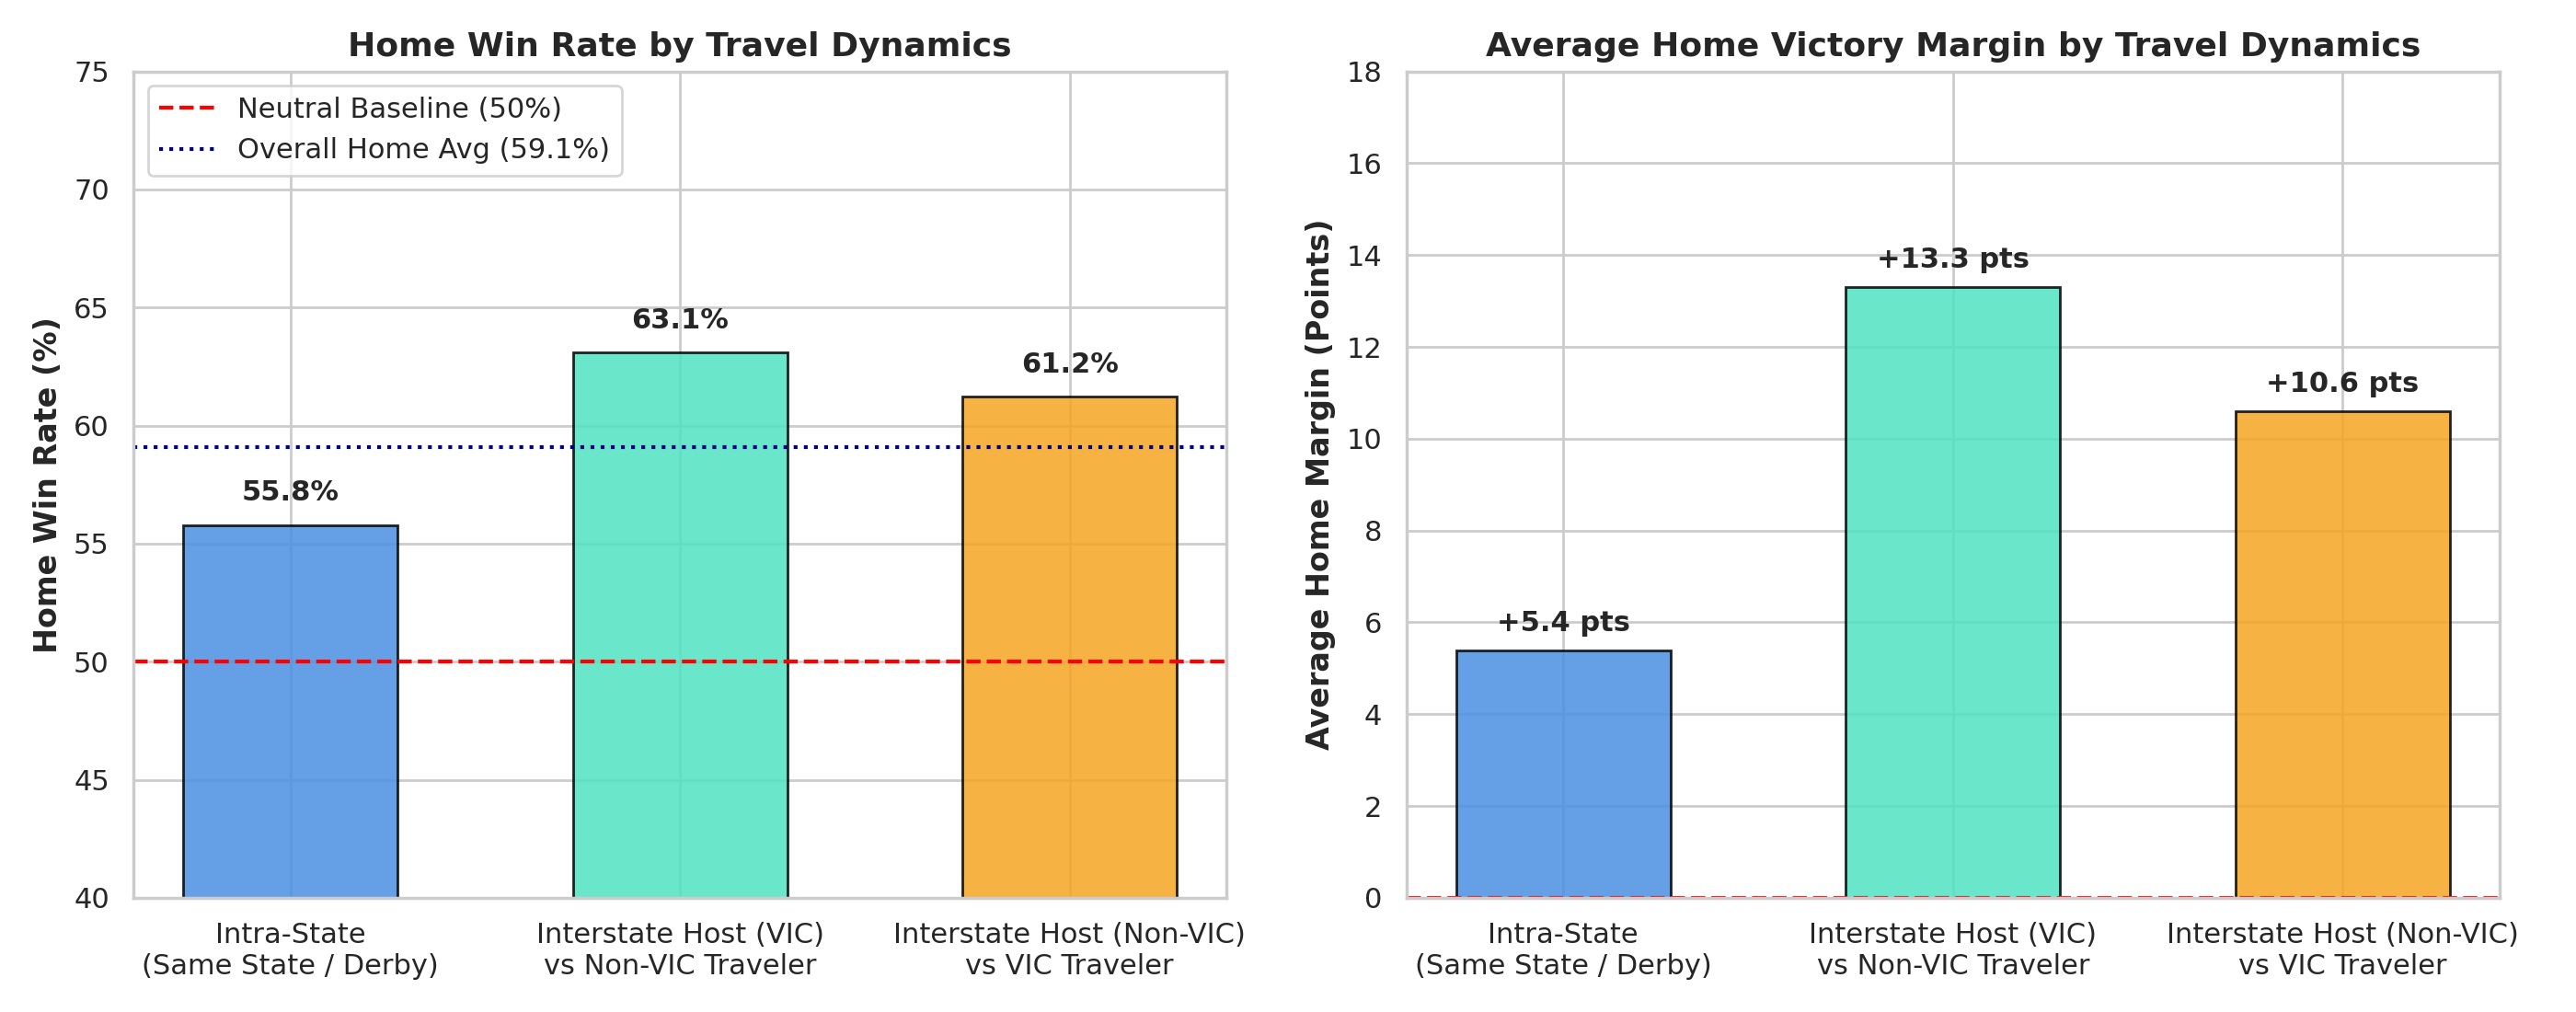

FIGURE 2: Impact of Recent Form Differential on Win Probability & Margin


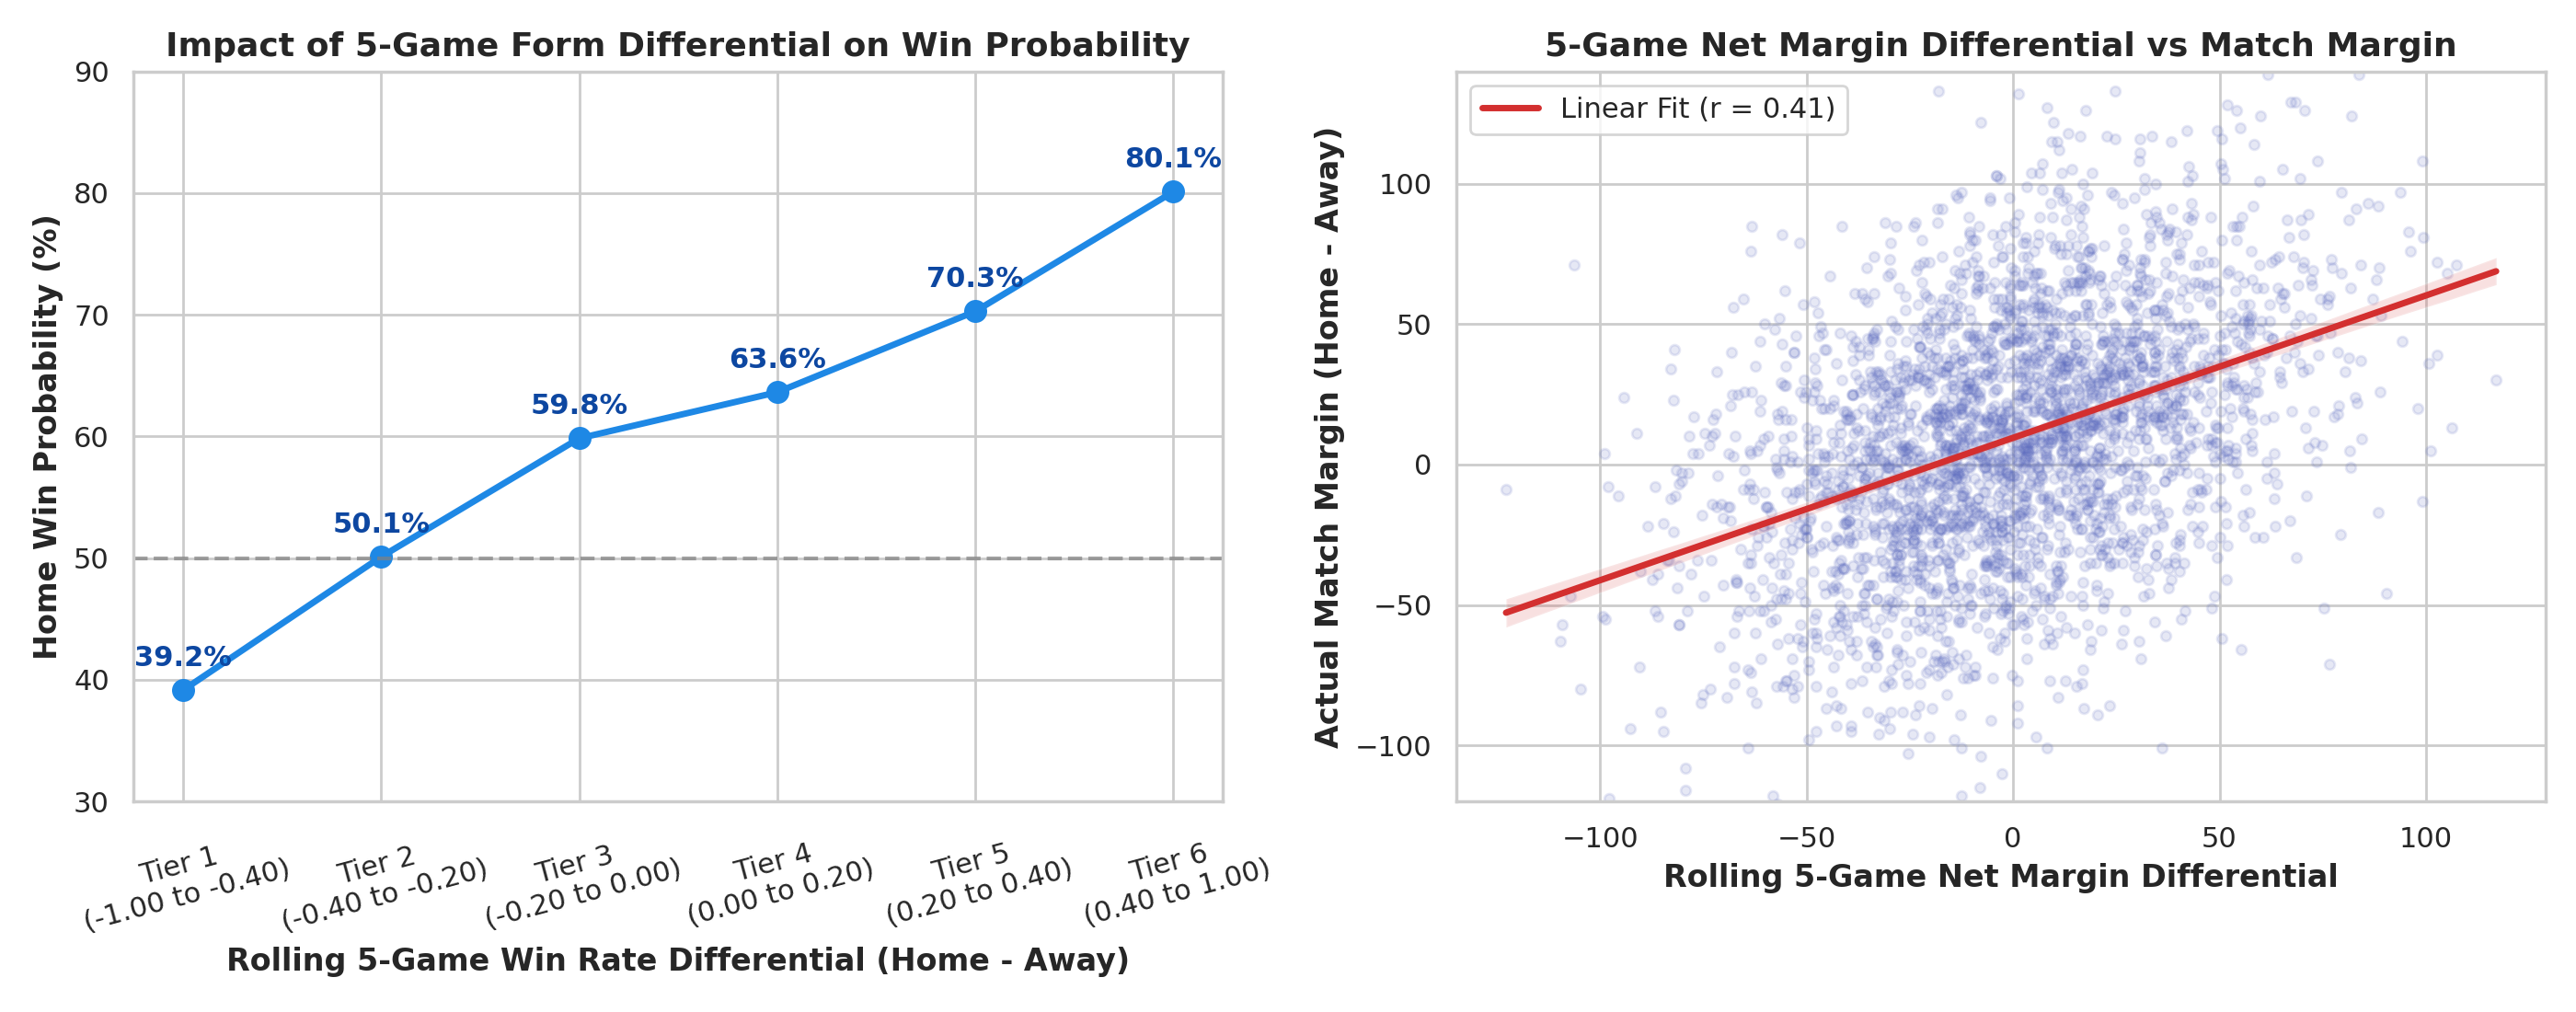

In [ ]:
# Display Visualizations 1 and 2
from IPython.display import Image, display

print("FIGURE 1: Home Ground Advantage & Interstate Travel Disadvantage")
display(Image(filename=f'{FIGURES_DIR}/fig1_home_advantage_interstate.png'))

print("FIGURE 2: Impact of Recent Form Differential on Win Probability & Margin")
display(Image(filename=f'{FIGURES_DIR}/fig2_recent_form_win_prob.png'))

FIGURE 3: Rest Intervals & Fatigue Turnaround Impact


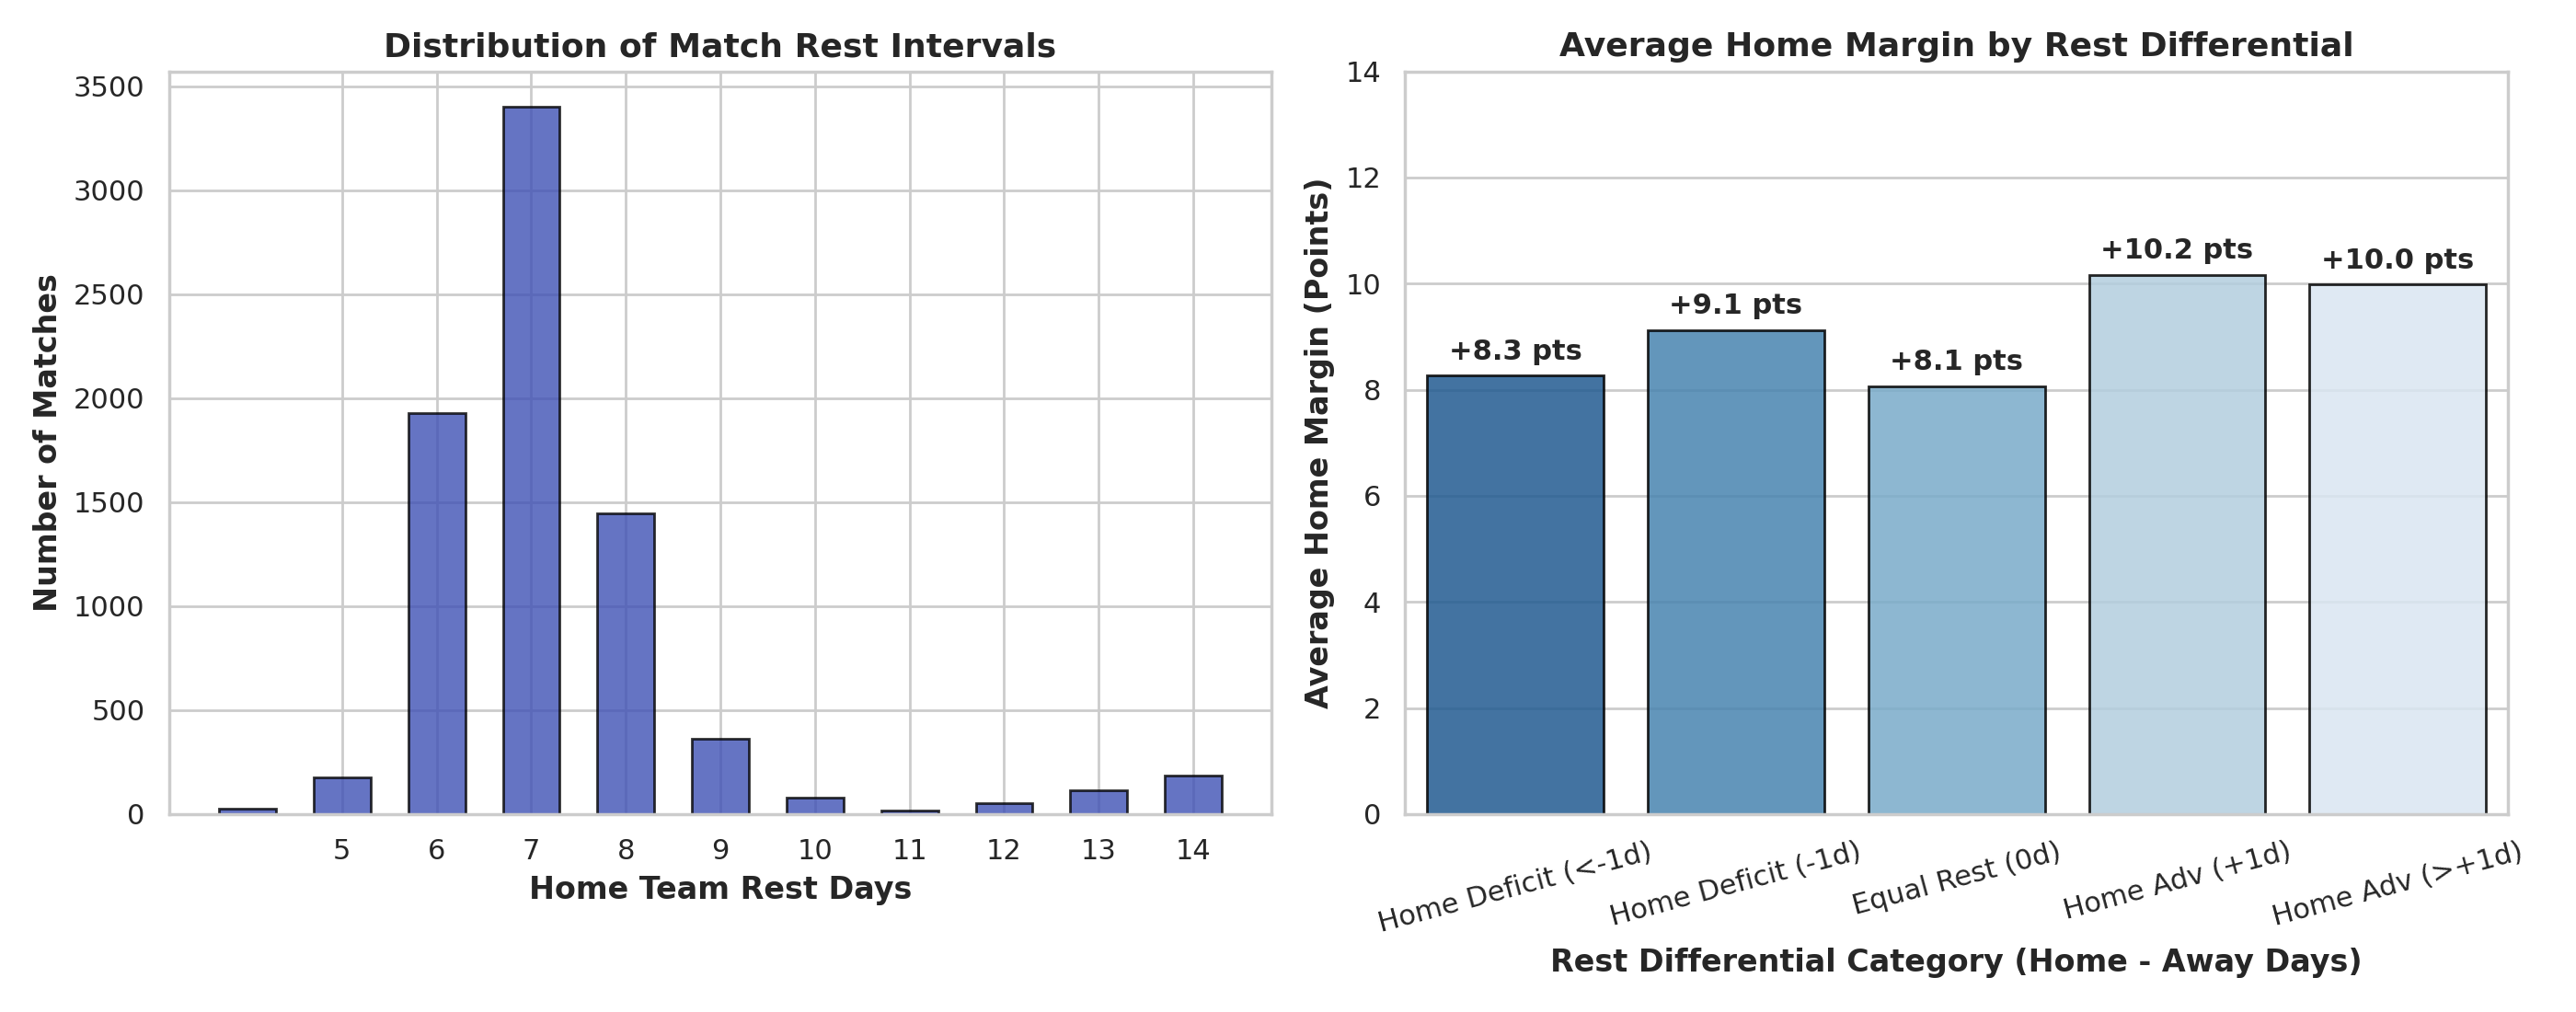

FIGURE 4: Pre-Match Ladder Rank Advantage vs Actual Match Margin


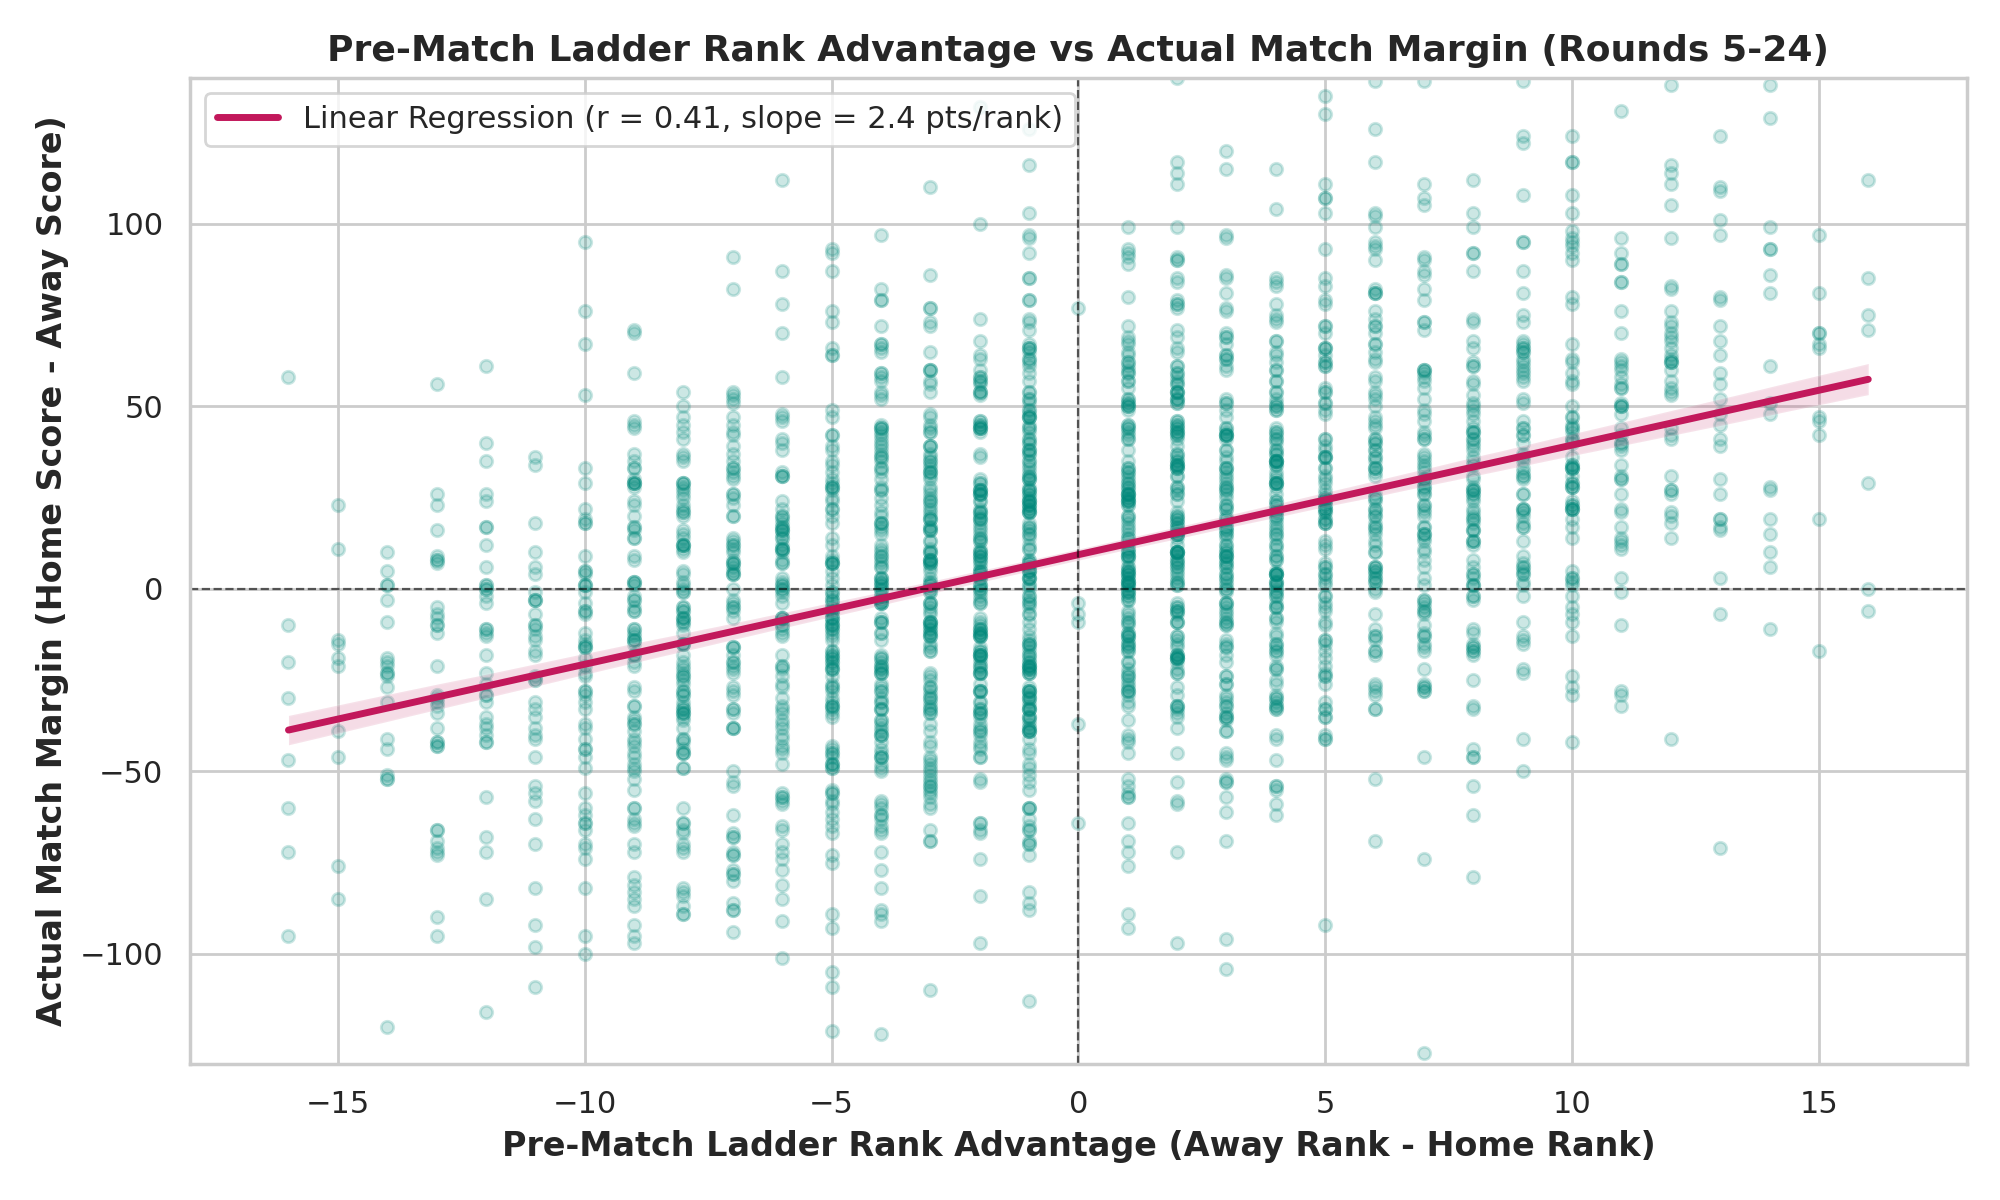

In [ ]:
# Display Visualizations 3 and 4
print("FIGURE 3: Rest Intervals & Fatigue Turnaround Impact")
display(Image(filename=f'{FIGURES_DIR}/fig3_rest_turnaround_impact.png'))

print("FIGURE 4: Pre-Match Ladder Rank Advantage vs Actual Match Margin")
display(Image(filename=f'{FIGURES_DIR}/fig4_ladder_rank_vs_margin.png'))

FIGURE 5: Venue Dominance & Crowd Scale across Major AFL Grounds


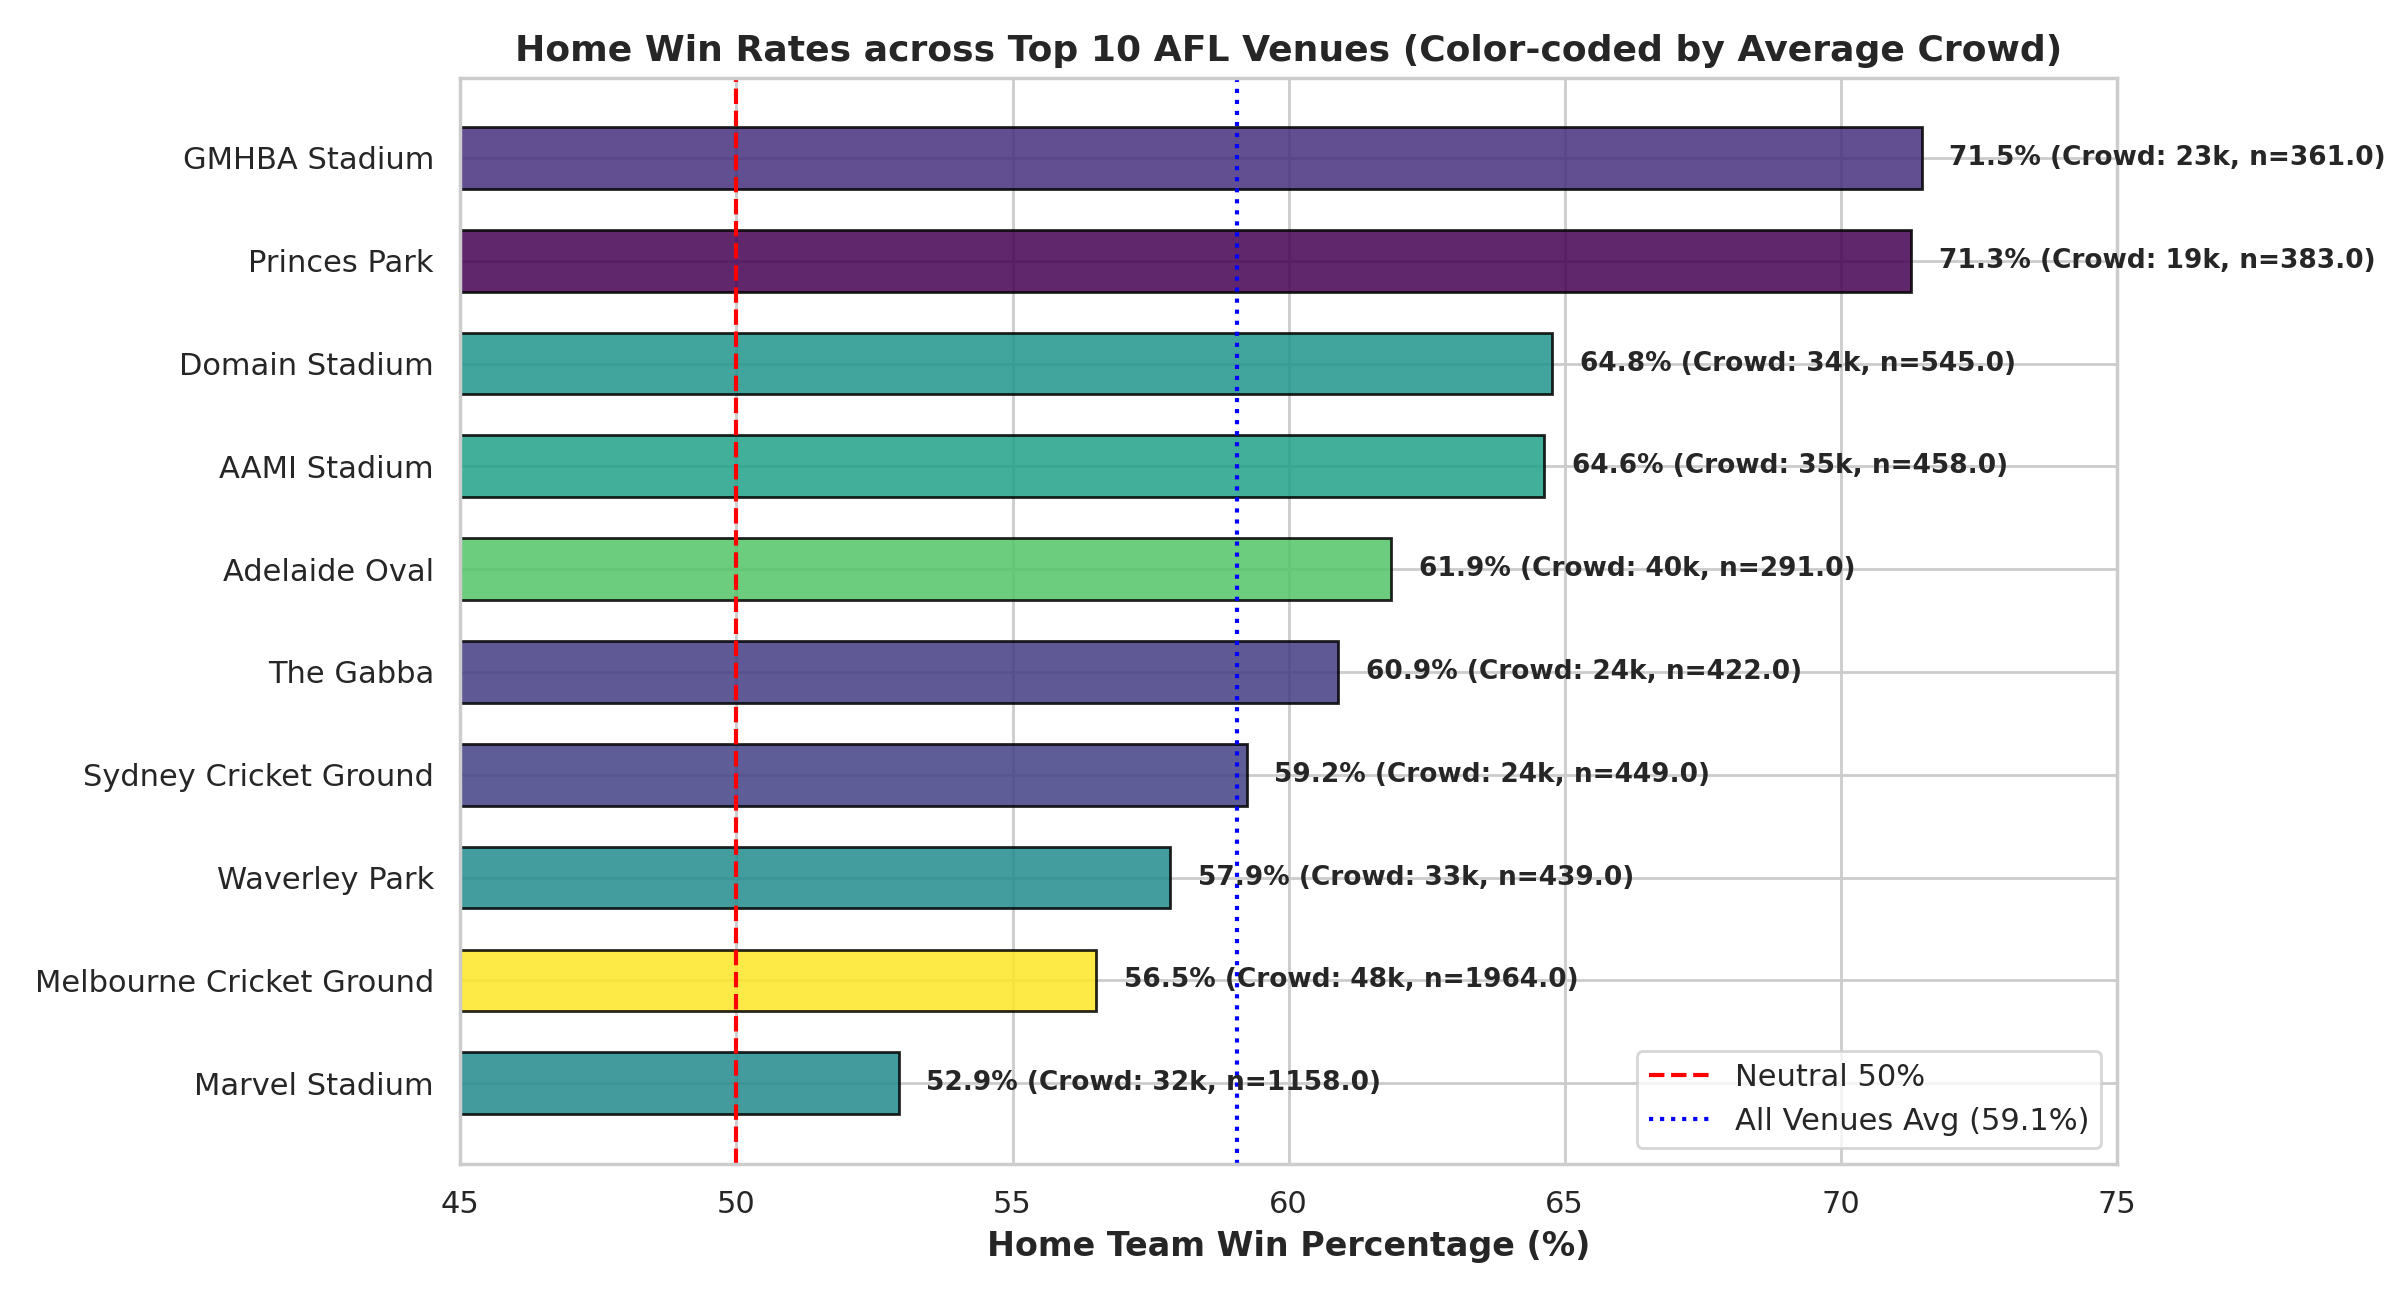

FIGURE 6: Player Position Distributions & Consistency Profile


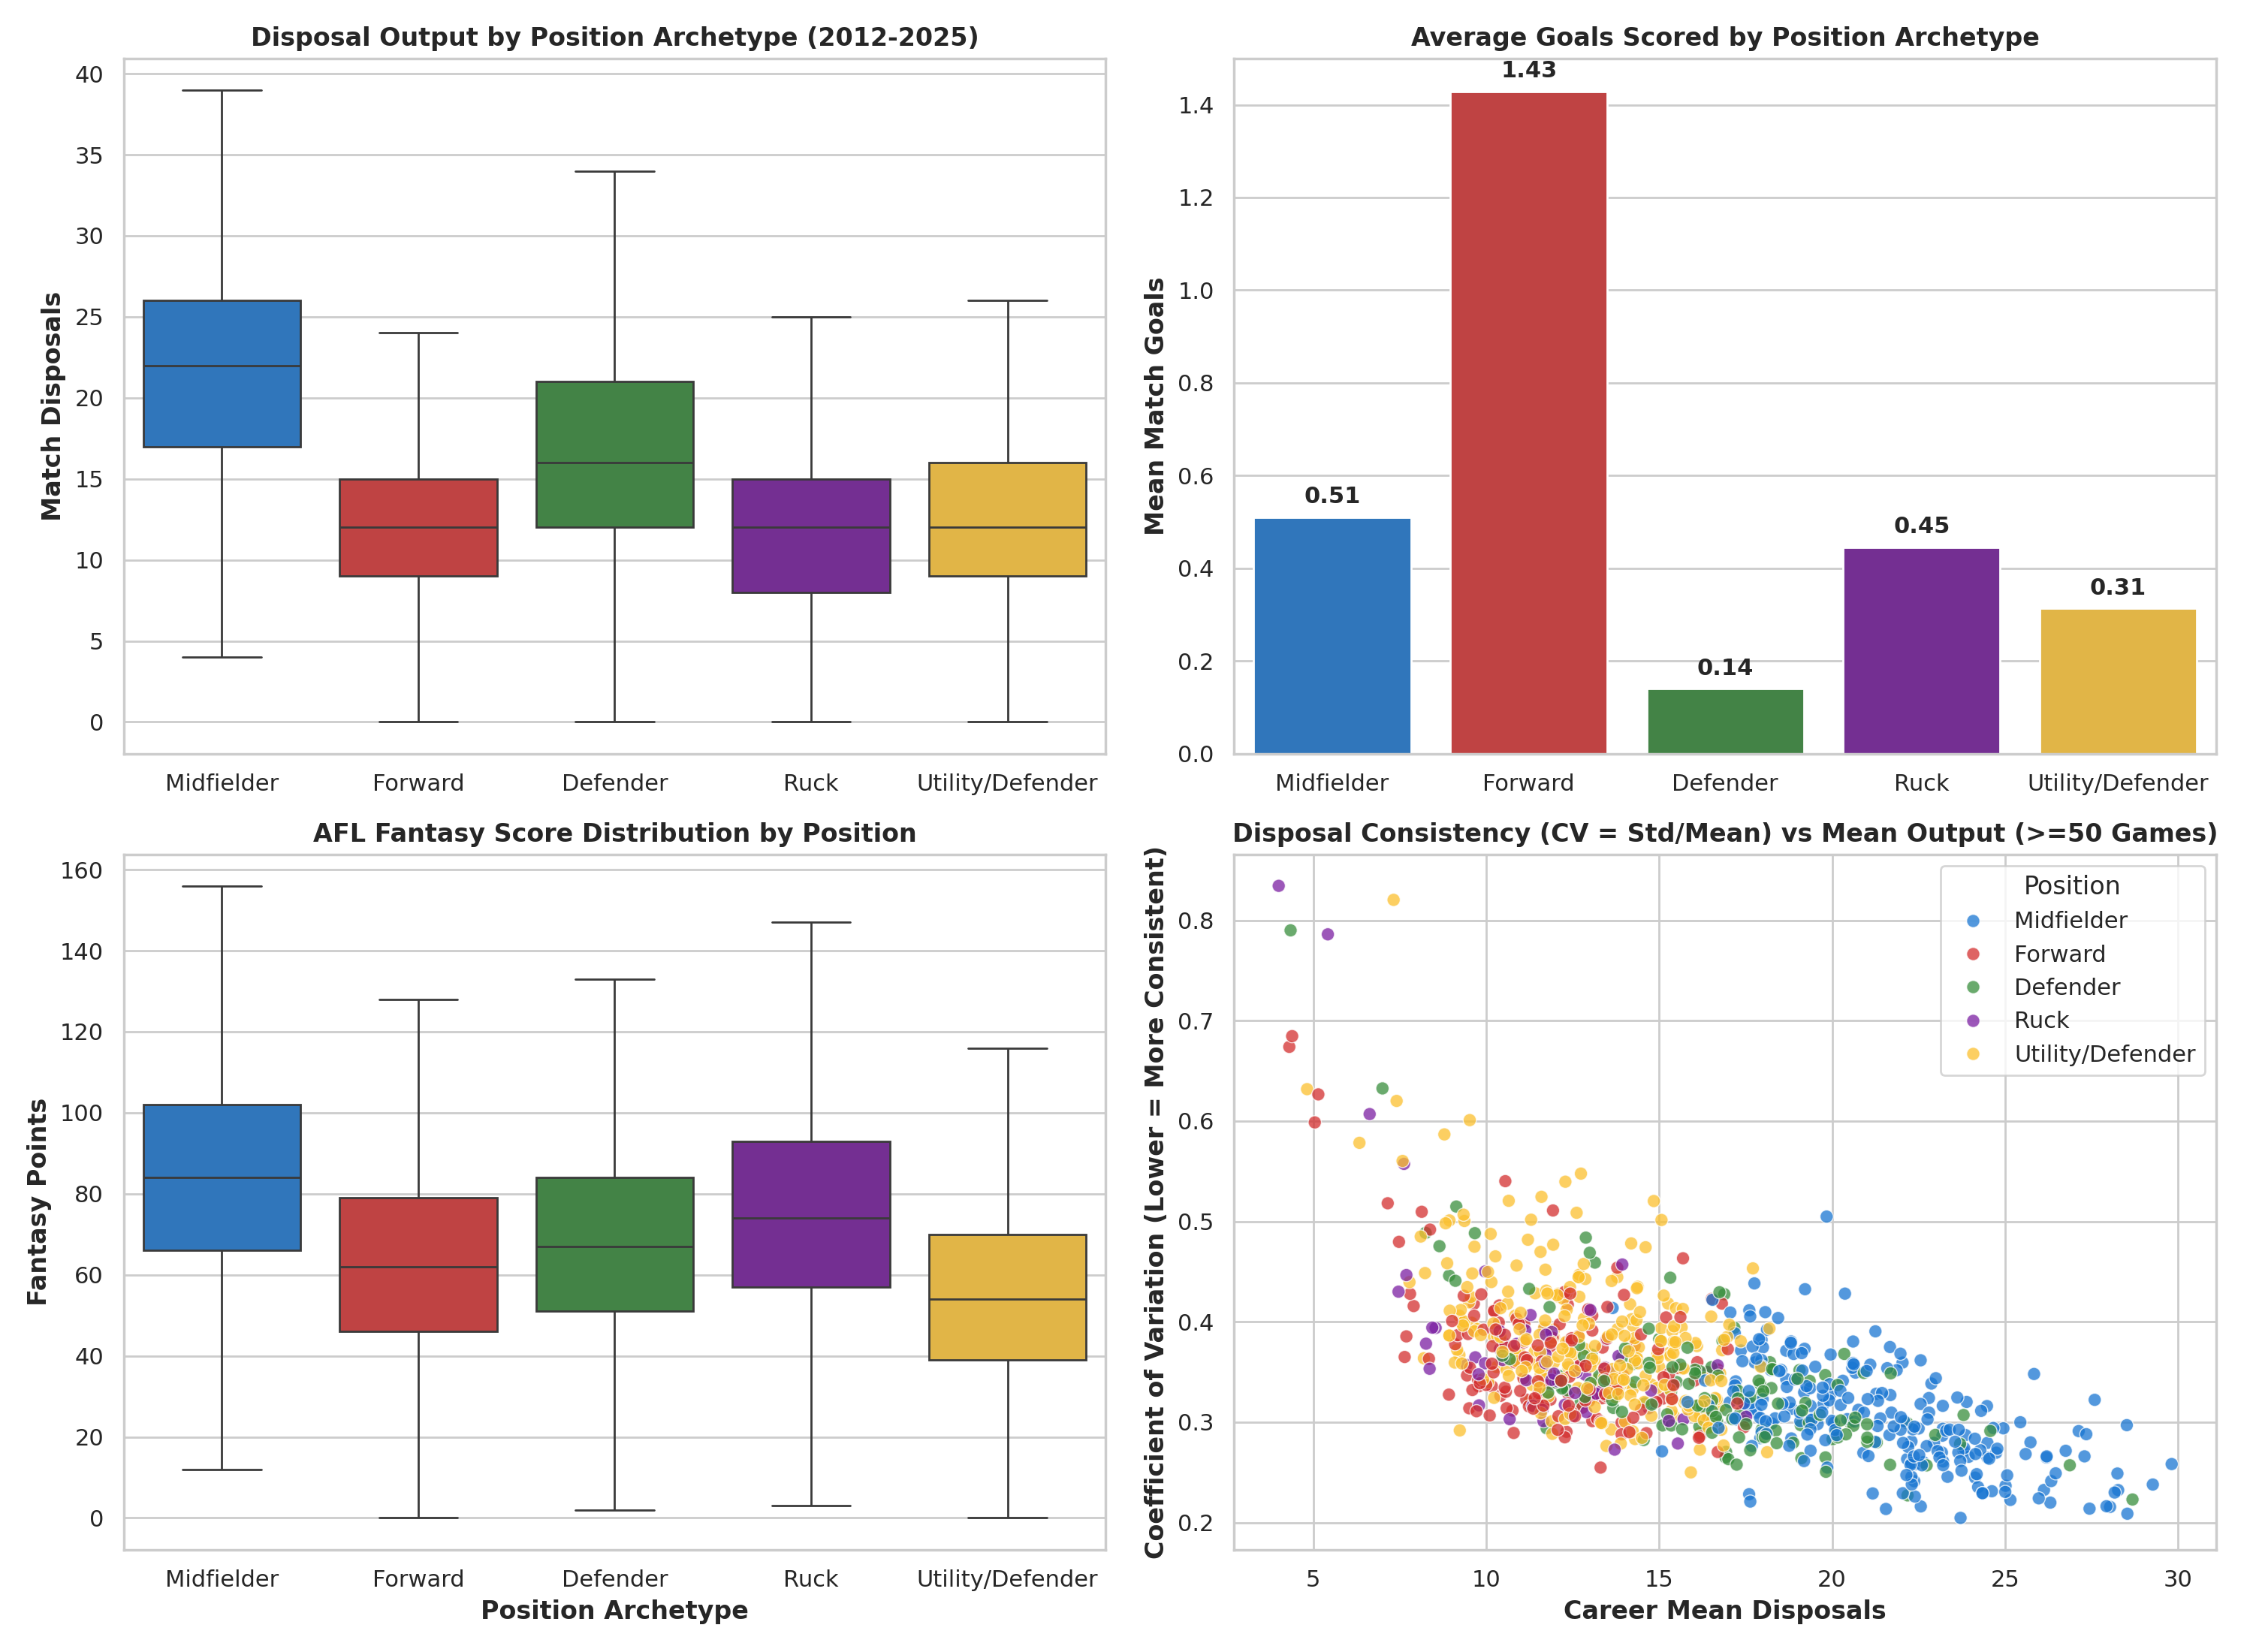

In [ ]:
# Display Visualizations 5 and 6
print("FIGURE 5: Venue Dominance & Crowd Scale across Major AFL Grounds")
display(Image(filename=f'{FIGURES_DIR}/fig5_venue_dominance.png'))

print("FIGURE 6: Player Position Distributions & Consistency Profile")
display(Image(filename=f'{FIGURES_DIR}/fig6_player_positions_distributions.png'))

---
## Task 4: Feature Engineering Pipeline (Strict Zero-Leakage)

To guarantee that models trained on these features can be deployed in production without lookahead bias, all features for a match on date $T$ strictly utilize information from matches **prior to $T$** (`closed='left'` via `shift(1)`).

### Engineered Feature Sets:
1. **Team Rolling Form:** Pre-match win streaks, 3-game and 5-game rolling win rates, rolling points scored, rolling points conceded, and form differentials (`roll_win_5_diff`, `roll_margin_5_diff`).
2. **Contextual & Rest Indicators:** Pre-match days of rest (`home_days_rest`, `away_days_rest`, `rest_diff`), interstate travel flags (`is_interstate_match`, `away_interstate_travel`).
3. **Head-to-Head & Venue Experience:** Expanding H2H win rate, last-3 H2H record, and venue historical win percentage.
4. **Pre-Match Ladder Standings:** Cumulative premiership points, percentage, and round-entry ladder rank differential (`ladder_rank_diff`).
5. **Player Form & Role Features:** 3-game and 5-game rolling disposals/goals/fantasy averages, rolling standard deviation (consistency), H2H opponent averages, and tactical position archetype.

In [ ]:
# Verify Versioned Feature Tables
match_features_df = pd.read_parquet(f'{FEATURES_DIR}/afl_match_features_v1.parquet')
player_features_df = pd.read_parquet(f'{FEATURES_DIR}/afl_player_match_features_v1.parquet')

print(f"Versioned Match Features Table:  {match_features_df.shape[0]} rows, {match_features_df.shape[1]} columns")
print(f"Versioned Player Features Table: {player_features_df.shape[0]} rows, {player_features_df.shape[1]} columns")

# Inspect top predictive correlations with home_margin
corr_series = match_features_df.select_dtypes(include=[np.number]).corr()['home_margin'].drop(
    ['home_margin', 'home_team_win', 'home_score', 'away_score', 'is_draw', 'total_match_score']
).sort_values(ascending=False)

print("\n--- TOP FEATURE CORRELATIONS WITH HOME VICTORY MARGIN ---")
print(corr_series.head(8).to_string())
print("\n--- BOTTOM FEATURE CORRELATIONS (NEGATIVE / OPPONENT ADVANTAGE) ---")
print(corr_series.tail(5).to_string())

Versioned Match Features Table:  7904 rows, 51 columns
Versioned Player Features Table: 274089 rows, 26 columns

--- TOP FEATURE CORRELATIONS WITH HOME VICTORY MARGIN ---
roll_margin_5_diff    0.406903
ladder_rank_diff      0.395400
roll_win_5_diff       0.349872
roll_score_5_diff     0.321480
roll_win_3_diff       0.303994
home_roll_margin_5    0.291464
home_pre_match_pct    0.285267
home_roll_win_5       0.259387

--- BOTTOM FEATURE CORRELATIONS (NEGATIVE / OPPONENT ADVANTAGE) ---
away_roll_win_5        -0.223792
away_pre_match_pct     -0.259910
home_ladder_rank       -0.265209
away_roll_margin_5     -0.267719
roll_conceded_5_diff   -0.347418


---
## Task 5: Reproducible Train/Hold-Out Split & Prediction Ceiling

### 5.1 Why Random Splits are Fatal in Sports Time-Series
In sports forecasting, random $K$-fold cross-validation or uniform train-test splitting introduces catastrophic **future-to-past data leakage**. 
1. **Lookahead Bias:** In an AFL season, team performance is highly autocorrelated and evolutionary (e.g. young players breaking out in Round 16, coaches altering tactical setups in Round 10, or late-season injury crises). 
2. **Causal Violation:** Training on Round 20 matches to predict Round 4 matches provides the model with future knowledge of late-season team quality that was fundamentally unknowable at Round 4.
3. **Evaluation Validity:** A real-world prediction engine or betting system operates strictly forward in time. Therefore, the evaluation protocol must mirror production: training strictly on historical seasons and holding out the most recent seasons as out-of-sample test sets.

### 5.2 Reproducible Temporal Partition Protocol
We partition the dataset using `features.get_time_based_split`:
- **Training Set:** Seasons $< 2024$ (7,472 match rows, 254,216 player-game rows).
- **Validation Set:** Season $2024$ (216 match rows, 9,937 player-game rows).
- **Out-of-Sample Test Set:** Season $2025$ (216 match rows, 9,936 player-game rows).

### 5.3 Realistic Prediction Ceiling & Leakage Integrity
In professional Australian Rules Football, outcomes are inherently stochastic. The bounce of an elliptical ball, microclimatic ground moisture, sudden in-game concussions/soft-tissue injuries, and subjective umpire whistle calls introduce irreducible aleatoric uncertainty. The empirical prediction ceiling established by leading quantitative AFL models (Squiggle consensus, Matter of Stats, Footy Forecaster) ranges strictly between **67% and 72% match win accuracy** (log loss $\approx 0.58-0.62$). Any model reporting $>80\%$ or "near-perfect" accuracy is an indisputable red flag indicating target leakage (e.g., incorporating in-match counting stats like total inside-50s or disposal tallies) or forward lookahead bias.

In [ ]:
# Execute Reproducible Temporal Split
train_mf, val_mf, test_mf = features.get_time_based_split(match_features_df, split_year=2024, test_year=2025)
train_pf, val_pf, test_pf = features.get_time_based_split(player_features_df, split_year=2024, test_year=2025)

print("=== REPRODUCIBLE TIME-BASED PARTITION SUMMARY ===")
print(f"Match Table  -> Train (<2024): {len(train_mf)} | Val (2024): {len(val_mf)} | Test (2025): {len(test_mf)}")
print(f"Player Table -> Train (<2024): {len(train_pf)} | Val (2024): {len(val_pf)} | Test (2025): {len(test_pf)}")

# Verify zero temporal overlap
assert train_mf['year'].max() < 2024, "Leakage: Train set contains 2024+ data!"
assert val_mf['year'].unique() == [2024], "Leakage: Validation set not strictly 2024!"
assert test_mf['year'].unique() == [2025], "Leakage: Test set not strictly 2025!"
print("\nTemporal integrity assertion passed: Zero forward leakage across partitions.")

=== REPRODUCIBLE TIME-BASED PARTITION SUMMARY ===
Match Table  -> Train (<2024): 7472 | Val (2024): 216 | Test (2025): 216
Player Table -> Train (<2024): 254216 | Val (2024): 9937 | Test (2025): 9936

Temporal integrity assertion passed: Zero forward leakage across partitions.


---
## Deliverables Summary & Day 2 Hand-off

1. **Versioned Artifacts Created:**
   - `data/features/afl_match_features_v1.parquet` (0.66 MB) & `.csv` (3.15 MB)
   - `data/features/afl_player_match_features_v1.parquet` (5.44 MB) & `.csv` (52.69 MB)
   - `data_dictionary_and_targets.pdf` (1-page formal data dictionary & target contract)
   - `data_dictionary_and_targets.md` (Contract markdown reference)
   - `figures/` (6 high-resolution exploratory & predictive relationship charts)
2. **Day 2 Modeling Hand-off Contract:**
   - All Day 2 match-winner models (Logistic Regression, XGBoost, LightGBM, Margin Regressors) must train on `train_mf`, tune hyperparameters on `val_mf`, and report final out-of-sample metrics exclusively on `test_mf`.
   - Realistic target performance benchmark: **68–71% accuracy**, **MAE ~28–32 points** on victory margin.